# AIR QUALITY PREDICTION USING REGRESSOR

Lets import required libraries to the project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
! pip install numpy

Lets extract the data from the file

In [2]:
df = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')


In [3]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng,Cluster
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,44.7444,44.2031,0
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-5.2900,-44.4900,0
2,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-11.2958,-41.9869,0
3,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,37.1667,15.1833,0
4,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,53.0167,20.8833,0


Lets Check the dataset have null values or not uisng heatmap

<Axes: >

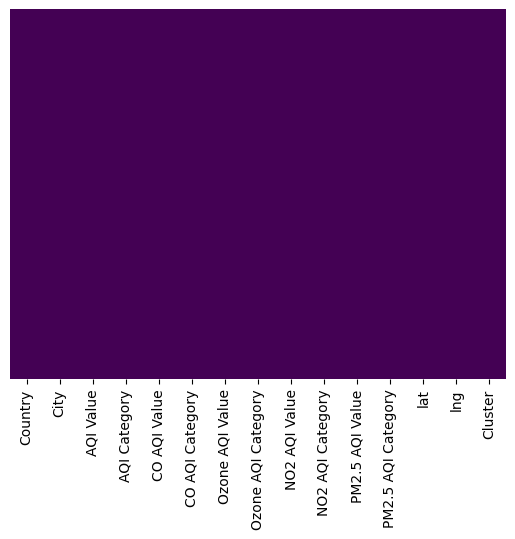

In [4]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [5]:
df.isnull().sum()

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
lat                   0
lng                   0
Cluster               0
dtype: int64

As we seen here PM 2.5 has one null values lets drop the one column beacause one values of drop will not effect to the model...

In [6]:
df = df.dropna()

In [7]:
X = df.iloc[:,:-1]  ##Independent Features, 
#In this we just drop the last feature and consider reamaining features as 
#independent features

Y = df.iloc[:,-1] ##Dependent Features,
##In this we just drop all the feature instaead last features
#for dependent features

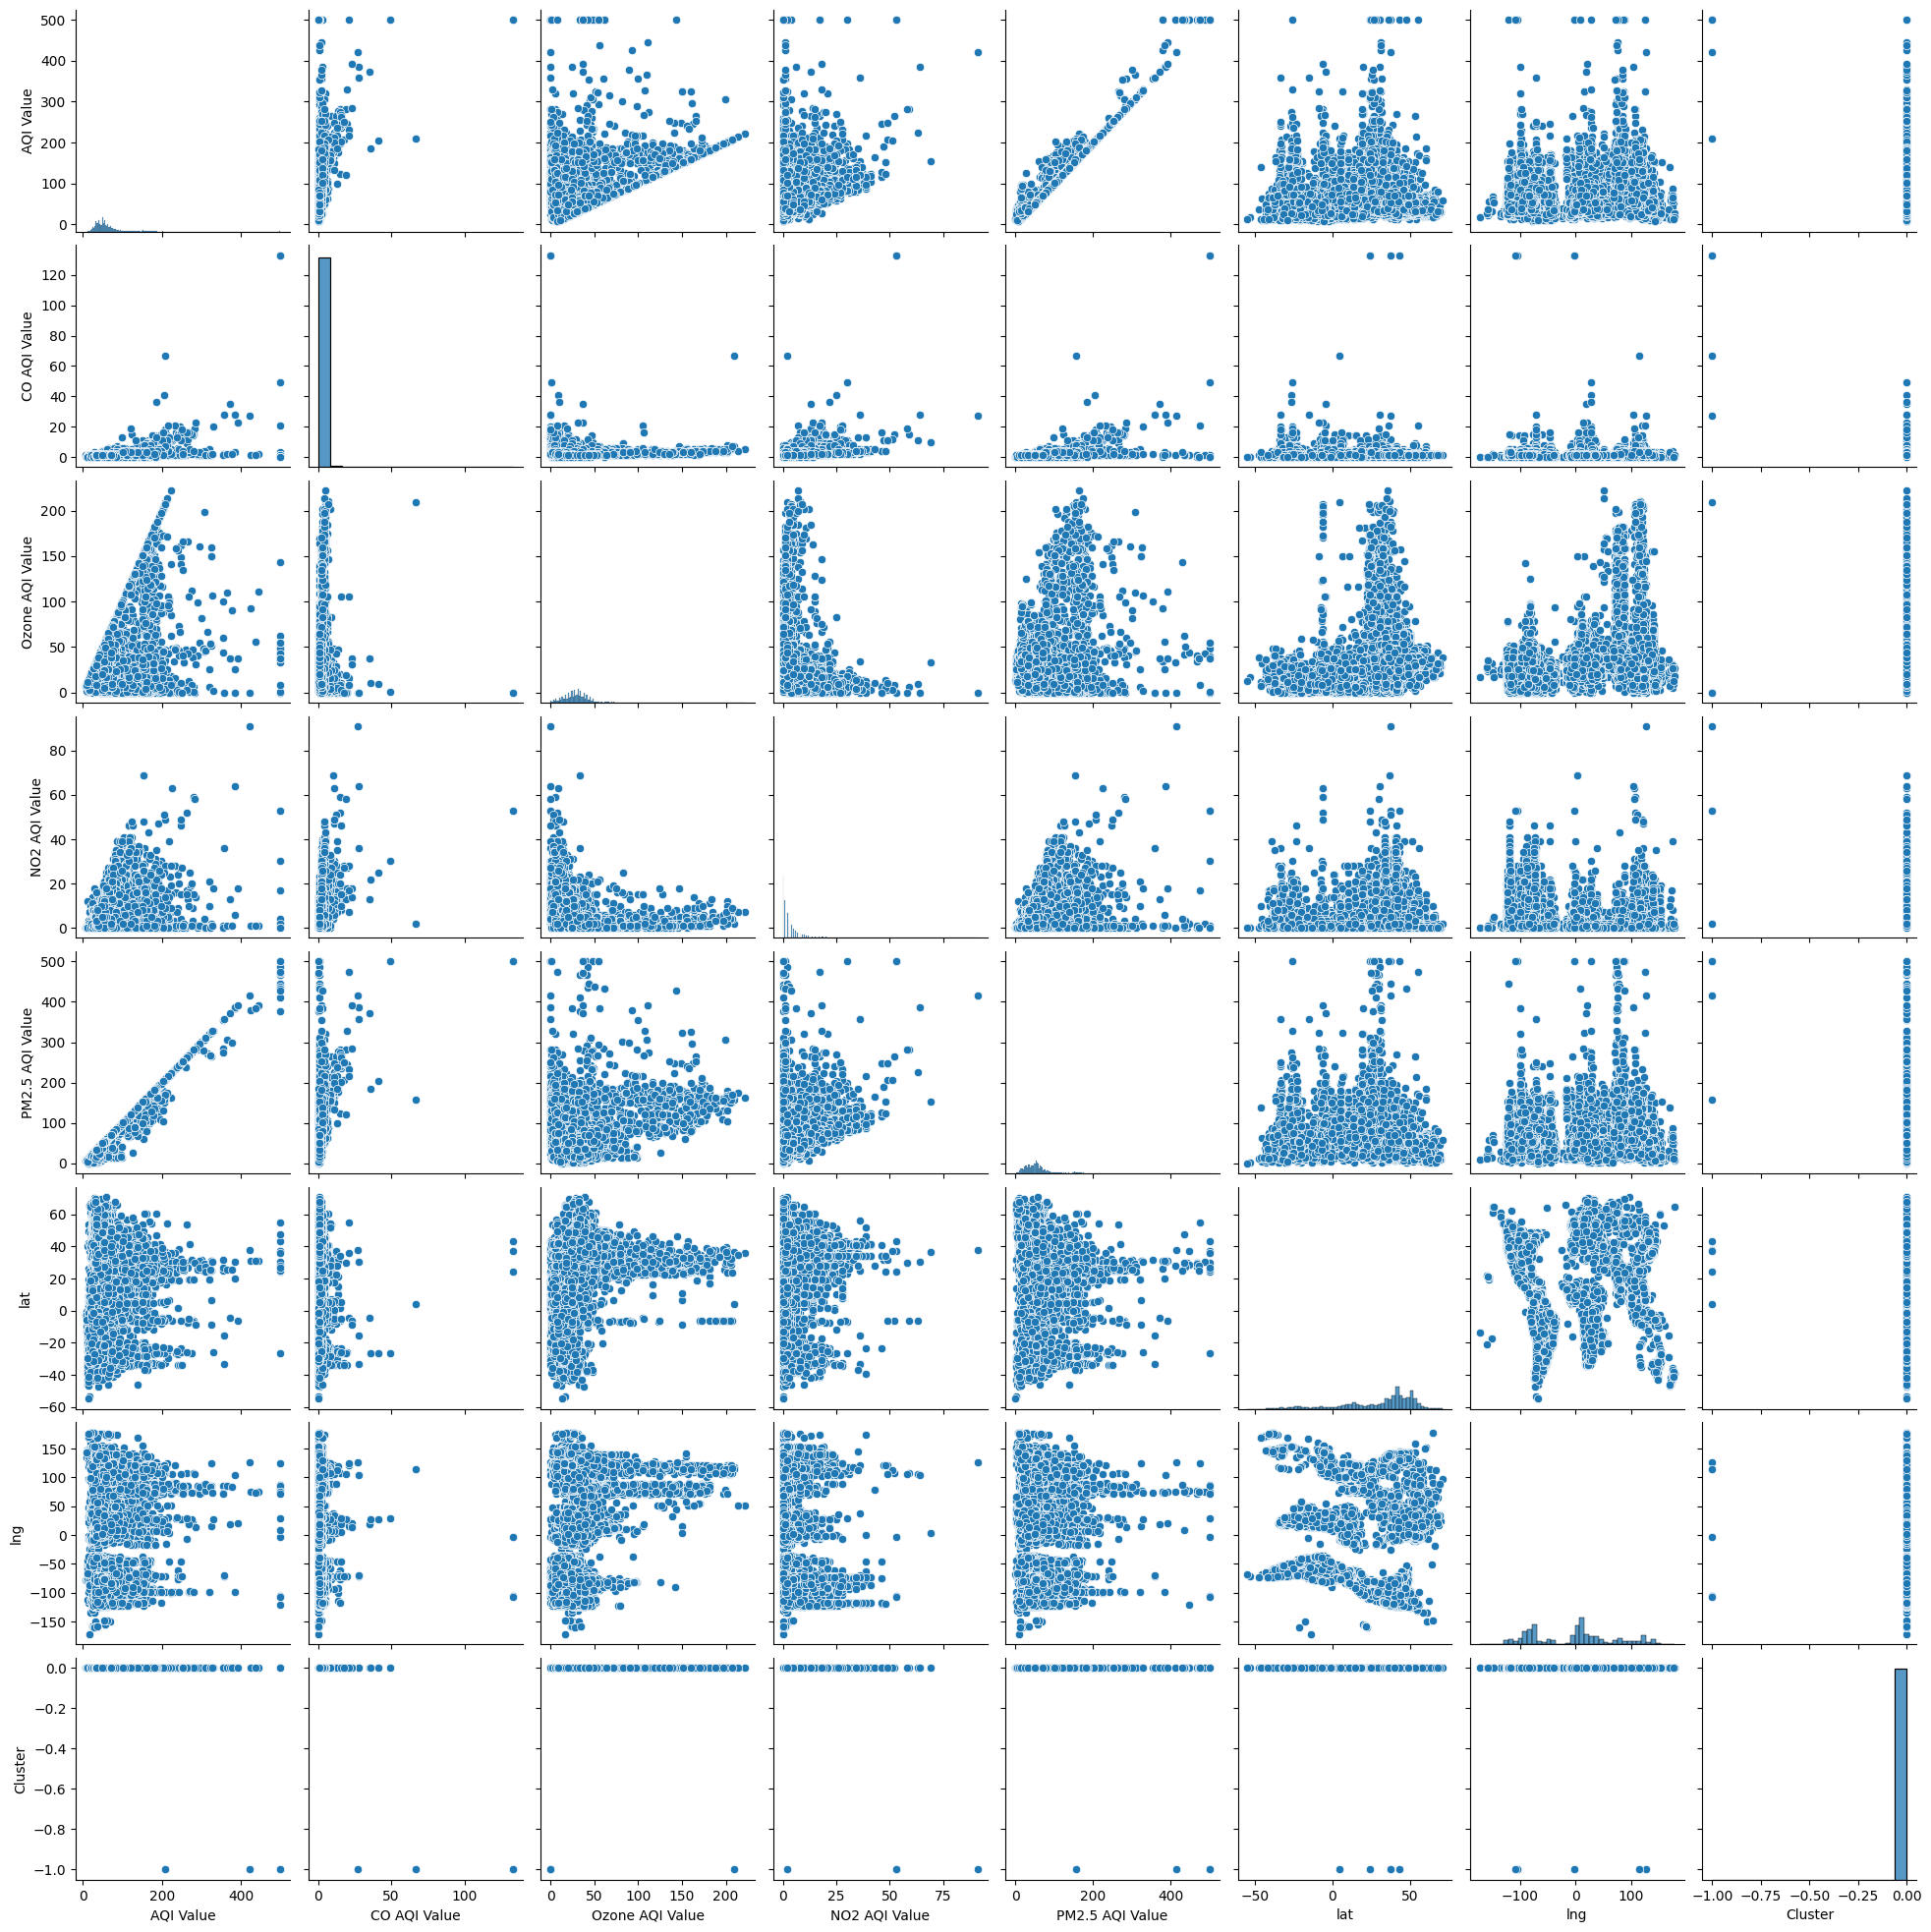

In [8]:
sns.pairplot(df)

### Correlation Matrix with Heatmap
Correlation states how the features are related to each other or the target variable.

Correlation can be positive (increase in one value of feature increases the value of the target variable) or negative (increase in one value of feature decreases the value of the target variable)

Heatmap makes it easy to identify which features are most related to the target variable, we will plot heatmap of correlated features using the seaborn library.

              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3            Good               39               Good              2   
4            Good               34               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category      lat      lng  
0    

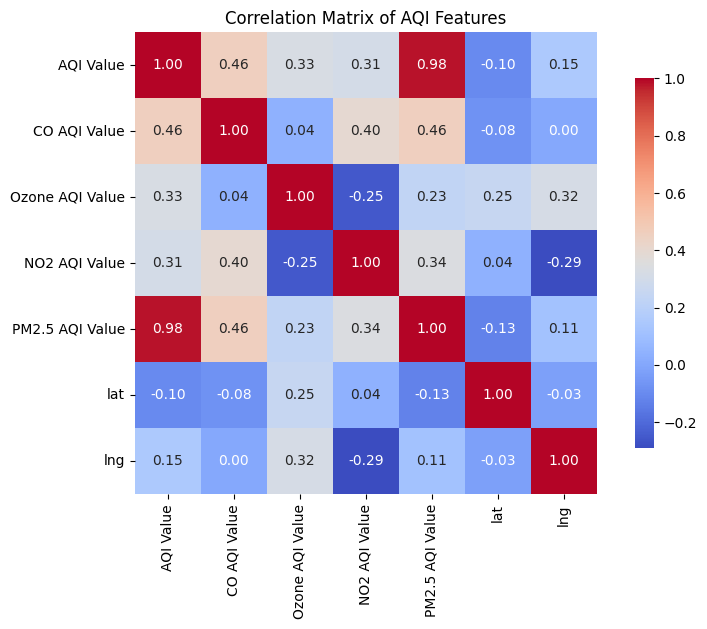

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Display the first few rows of the dataset
print(data.head())

# Check the data types of each column
print(data.dtypes)

# Select only numeric columns for correlation analysis
numeric_features = data.select_dtypes(include=[np.number])

# Compute correlation matrix
corrmat = numeric_features.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(corrmat)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of AQI Features')
plt.show()

### Feature Importance


In [26]:
! pip install scikit-learn


     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     -------------------------------------- 60.8/60.8 kB 815.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.4/11.0 MB 7.4 MB/s eta 0:00:02
   - -------------------------------------- 0.5/11.0 MB 5.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.4/11.0 MB 9.9 MB/s eta 0:00:01
   ------- -------------------------------- 1.9/11.0 MB 10.2 MB/s eta 0:00:01
   -------- ------------------------------- 2.3/11.0 MB 9.8 MB/s eta 0:00:01
   --------- ------------------------------ 2.6/11.0 MB 9.6 MB/s eta 0:00:01
   ----------- ---------------------------- 3.1/11.0 MB 9.4 MB/s eta 0:00:01
   ------------ --------------------------- 3.4/11.0 MB 9.3 MB/s eta 0:00:01
   -------------- ------------------------- 4.1/11.0 MB 9.6 MB/s eta 0:00:01
   --------

In [19]:
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Display the first few rows of the dataset
print(data.head())

# Check the data types of each column
print(data.dtypes)

# Select features (X) and target (Y)
# Assuming we want to predict 'AQI Value' based on other features
X = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]
Y = data['AQI Value']  # This should be numeric

# Convert categorical columns if necessary (e.g., 'AQI Category')
# If you need to encode categorical variables, do so here
# For example, if you want to drop non-numeric columns:
data.drop(columns=['Country', 'City', 'AQI Category'], inplace=True)

# Check for any non-numeric values in X or Y
print(X.isnull().sum())  # Check for missing values
print(Y.isnull().sum())

# Ensure that all features in X are numeric
X = X.apply(pd.to_numeric, errors='coerce')  # Convert to numeric, forcing errors to NaN
Y = pd.to_numeric(Y, errors='coerce')  # Convert target variable to numeric

# Drop any rows with NaN values created during conversion
X.dropna(inplace=True)
Y = Y[X.index]  # Align Y with X after dropping NaN rows

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Scale the features (important for some algorithms)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and fit the ExtraTreesRegressor model
model = ExtraTreesRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model (you can add more evaluation metrics if needed)
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')




              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3            Good               39               Good              2   
4            Good               34               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category      lat      lng  
0    

In [20]:
X.head()

,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
0,1,36,0,51
1,1,5,1,41
2,1,5,1,41
3,1,39,2,66
4,1,34,0,20


Lets Check the which features have more values using ensemble techniques of Feature selection

In [21]:
print(model.feature_importances_)

[0.01793692 0.05911356 0.00162207 0.92132745]


Lets visualize the data with top 5 features and top 5 features will aply to the model

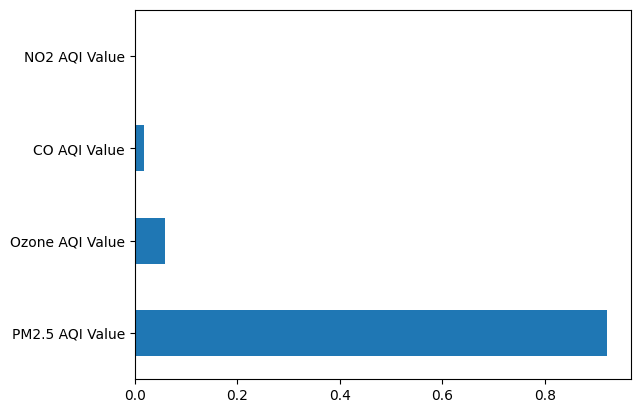

In [22]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

In first we apply the machine learning lets just see for the referebce comparison

## Train Test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=0)

## Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor 

In [25]:
dtree=DecisionTreeRegressor(criterion='mse')

In [26]:
from sklearn.tree import DecisionTreeRegressor

# Correctly specify the criterion
dtree = DecisionTreeRegressor(criterion="squared_error")
dtree.fit(X_train, Y_train)


DecisionTreeRegressor()

In [27]:
dtree = DecisionTreeRegressor()
dtree.fit(X_train, Y_train)


DecisionTreeRegressor()

In [28]:
print("Coefficient of determination R^2 <-- on train set: {}".format(dtree.score(X_train, Y_train)))

Coefficient of determination R^2 <-- on train set: 1.0


In [29]:
print("Coefficient of determination R^2 <-- on test set: {}".format(dtree.score(X_test, Y_test)))

Coefficient of determination R^2 <-- on test set: 0.9991902272958251


In [30]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(dtree,X,Y,cv=5)

In [31]:
score.mean()

np.float64(0.9973819234070002)

## Model Evaluation

In [32]:
prediction = dtree.predict(X_test)

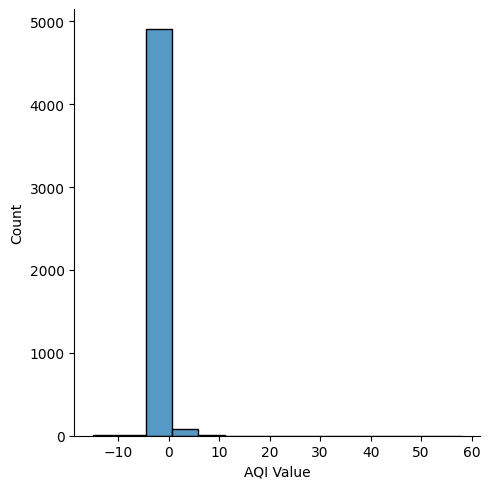

In [33]:
sns.displot(Y_test - prediction)

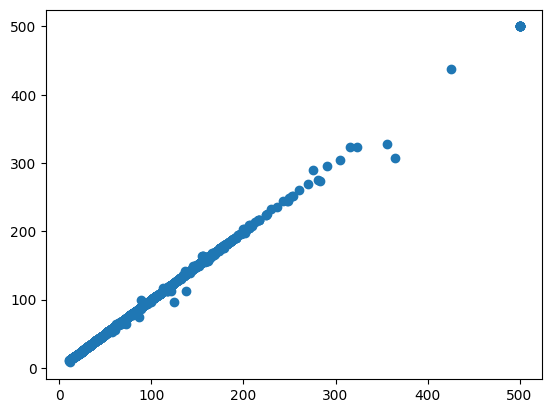

In [34]:
plt.scatter(Y_test,prediction)